# CAMELS preprocessing v3.0
Pipeline di preprocessing con **label dal catalogo FoF/SubFind** (decisione del relatore, incontro 29/09).

- **Input X a un solo canale** (densità SPH): il canale h_sph è eliminato perché h ∝ ρ^(−1/3), quindi la mappa di smoothing lengths non aggiunge informazione nuova (misurato in v2.x: Spearman ρ = +0.81 ≈ 65% varianza condivisa).
- **Label Y dal catalogo** `groups_090.hdf5`: maschere binarie periodiche ai centri del catalogo dentro la fetta, raggio R200c (`Group_R_Crit200`). La verità-terra assunta è FoF+SubFind: il confronto rete-vs-verità resta onesto e paragonabile alla pratica della community.
- Le funzioni di peak-finding/radius/heatmap della fase "catalog-free" (v2.2/v2.3) restano come **diagnostica opzionale** (`RUN_PEAK_DIAGNOSTICS`) e documentazione dell'esplorazione per la tesi.

## 1) Configurazione, percorsi e parametri
Definizione degli input/output e dei parametri fisici/numerici usati in tutta la pipeline.
In v3 compaiono: `GROUPS_PATH` (catalogo aloni), `MIN_RADIUS_PX` (pavimento disegno label),
`HALO_WEIGHTING` (assegnazione aloni alle fette), `RUN_PEAK_DIAGNOSTICS` (flag diagnostica esplorativa).

In [1]:
import os
import numpy as np
import h5py
import hdf5plugin                       # necessario per la compressione usata in CAMELS
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter, gaussian_filter
import sphviewer2                       # type: ignore

# ── Percorsi file ─────────────────────────────────────────────────────────────
SNAPSHOT_PATH = r"C:\Users\kekko\Downloads\Python\TESI\CAMELS_data\snapshot_090.hdf5"
GROUPS_PATH   = r"C:\Users\kekko\Downloads\Python\TESI\CAMELS_data\groups_090.hdf5"
OUTPUT_DIR    = r"C:\Users\kekko\Downloads\Python\TESI\CAMELS_data\preprocessed_v3.0"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Parametri SPH / immagine (invariati) ─────────────────────────────────────
N_NEIGHBORS_H  = 32
TARGET_CELLS   = 4
R_MAX_LEVEL    = 10
IMG_SIZE       = 2 ** R_MAX_LEVEL    # 1024

# ── Slicing ───────────────────────────────────────────────────────────────────
N_SLICES = 25    # fisso, indicato dal prof. Benitez

# ── Label da catalogo FoF/SubFind (decisione 29/09) ──────────────────────────
N_MIN_PARTICLES = 100            # N_min di SubFind → MASS_CUT fisico = 100 × m_DM
MIN_RADIUS_PX   = 1.5            # pavimento disegno: sotto ~1.5 px l'alone non è risolvibile
HALO_WEIGHTING  = "center"       # "center" (convenzione v1) | "fraction" (vedi 2c, da decidere col prof)

# ── Diagnostica picchi (fase esplorativa v2.x, opzionale) ─────────────────────
RUN_PEAK_DIAGNOSTICS = True      # False salta entirely il blocco peak-finding/massa d'apertura
PEAK_MIN_DISTANCE     = 5      # px: due picchi entro N px vengono uniti
PEAK_THRESHOLD_SIG    = 2.5    # sigma sopra la mediana per accettare un picco
RADIUS_DROP_FACTOR    = np.e   # criterio 1/e: raggio dove ρ scende a peak/e
GAUSSIAN_SIGMA_FACTOR = 0.33   # σ_blob = R_px × factor (default CenterNet)
DEFAULT_RADIUS_PX     = 3.0    # raggio di fallback se stima dal profilo fallisce
TOL_MATCH             = 0.122  # Mpc/h (~5 px): tolleranza dedup inter-fetta (fissa!)

# ── Dataset ───────────────────────────────────────────────────────────────────
PATCH_SIZE      = 256
EPS             = 1e-10    # evita log(0)

print(f"{'IMG_SIZE':<24}: {IMG_SIZE} × {IMG_SIZE} px")
print(f"{'N_SLICES':<24}: {N_SLICES}")
print(f"{'PATCH_SIZE':<24}: {PATCH_SIZE} × {PATCH_SIZE} px")
print(f"{'Patches per immagine':<24}: {(IMG_SIZE // PATCH_SIZE)**2}")
print(f"{'Patch totali (1 sim)':<24}: {N_SLICES * (IMG_SIZE // PATCH_SIZE)**2}")
print(f"{'Input channels':<24}: 1  (densità SPH; CH2 h_map ELIMINATO in v3)")
print(f"{'Output directory':<24}: {OUTPUT_DIR}")

IMG_SIZE                : 1024 × 1024 px
N_SLICES                : 25
PATCH_SIZE              : 256 × 256 px
Patches per immagine    : 16
Patch totali (1 sim)    : 400
Output directory        : C:\Users\kekko\Downloads\Python\TESI\CAMELS_data\preprocessed_v2.1


## 2) Caricamento snapshot, catalogo aloni, geometria delle slice e smoothing lengths
Lettura dello snapshot CAMELS **e del catalogo FoF+SubFind `groups_090.hdf5`** (GroupPos in ckpc/h,
GroupMass in 10¹⁰ M☉/h, Group_R_Crit200 in ckpc/h), calcolo della geometria della griglia e
caricamento/calcolo degli smoothing lengths.

In [2]:
# %% ── 2a. Caricamento snapshot ───────────────────────────────────────────────

with h5py.File(SNAPSHOT_PATH, "r") as f:
    header       = f["Header"].attrs
    Lbox_ckpc    = float(header["BoxSize"])
    Lbox         = Lbox_ckpc / 1000.0
    redshift     = float(header["Redshift"])
    h_cosmo      = float(header["HubbleParam"])
    omega_m      = float(header["Omega0"])
    mass_table   = np.asarray(header["MassTable"], dtype=np.float64)
    dm_mass_1e10 = mass_table[1]
    dm_mass      = dm_mass_1e10 * 1e10    # M_sun/h

    pos = np.asarray(f["PartType1/Coordinates"][:], dtype=np.float64) / 1000.0
    vel = np.asarray(f["PartType1/Velocities"][:],  dtype=np.float64)

x = np.ascontiguousarray(pos[:, 0])
y = np.ascontiguousarray(pos[:, 1])
z = np.ascontiguousarray(pos[:, 2])
n_particles = len(x)
m = np.full(n_particles, dm_mass, dtype=np.float64)

SLICE_DZ       = Lbox / N_SLICES
pixel_size_mpc = Lbox / IMG_SIZE

print("=== Snapshot summary ===")
print(f"  N particelle  : {n_particles:,}  ({round(n_particles**(1/3))}³)")
print(f"  Box size      : {Lbox:.4f} Mpc/h  ({Lbox_ckpc:.1f} ckpc/h)")
print(f"  Redshift      : {redshift:.6f}")
print(f"  DM mass/part  : {dm_mass:.4e} M☉/h")
print(f"\n=== Slice geometry ===")
print(f"  N_SLICES      : {N_SLICES}")
print(f"  Slice Δz      : {SLICE_DZ:.4f} Mpc/h  ({SLICE_DZ*1000:.1f} ckpc/h)")
print(f"  Pixel size    : {pixel_size_mpc*1000:.2f} ckpc/h")

MASS_CUT_MSUN = N_MIN_PARTICLES * dm_mass
MASS_CUT_CAT  = MASS_CUT_MSUN / 1e10

print("=== Mass cut ===")
print(f"  MASS_CUT : {MASS_CUT_MSUN:.3e} M☉/h  ({MASS_CUT_CAT:.4f} × 10¹⁰ M☉/h)")
print(f"  r_min risolvibile : {2*pixel_size_mpc*1000:.2f} ckpc/h  (2 pixel)")

# %% ── 2b. Catalogo aloni FoF+SubFind (VERITÀ-TERRA delle label in v3) ────────
# GroupPos        : centro dell'alone (ridefinito energeticamente da SubFind: minima
#                   energia di legame, NON centro geometrico) in ckpc/h
# GroupMass       : massa in unità 1e10 M☉/h
# Group_R_Crit200 : raggio viriale a 200×ρ_crit in ckpc/h
CATALOG_DIR_KEYS = ["CatalogObject", "GROUPOBJECT", "Group", "FOF"]  # nomi alternativi comuni

with h5py.File(GROUPS_PATH, "r") as f:
    gname = next((k for k in CATALOG_DIR_KEYS if k in f), None)
    if gname is None:
        raise KeyError(f"Cartella catalogo non trovata in {GROUPS_PATH}. "
                       f"Chiavi presenti: {list(f.keys())}")
    grp = f[gname]
    print(f"=== Chiavi del gruppo \"{gname}\" ===")
    for k in grp.keys():
        try:
            print(f"  {k:<20} shape={grp[k].shape}  dtype={grp[k].dtype}")
        except AttributeError:
            print(f"  {k:<20} (dataset non raggiungibile)")

    cat_pos_ckpc   = np.asarray(grp["GroupPos"][:],          dtype=np.float64)
    cat_mass_1e10  = np.asarray(grp["GroupMass"][:],          dtype=np.float64)
    cat_rcrit_ckpc = np.asarray(grp["Group_R_Crit200"][:],    dtype=np.float64)

cat_pos_mpc   = cat_pos_ckpc / 1000.0          # → Mpc/h
cat_r200_mpc  = cat_rcrit_ckpc / 1000.0        # → Mpc/h
cat_mass_msun = cat_mass_1e10 * 1e10           # → M☉/h

sel = (cat_mass_1e10 >= MASS_CUT_CAT) & (cat_rcrit_ckpc > 0)
halo_x, halo_y, halo_z = cat_pos_mpc[sel, 0], cat_pos_mpc[sel, 1], cat_pos_mpc[sel, 2]
halo_mass, halo_r200   = cat_mass_msun[sel],  cat_r200_mpc[sel]
n_cat_total, n_cat_sel = int(len(cat_mass_1e10)), int(sel.sum())

print("\n=== Catalogo aloni (FoF+SubFind) ===")
print(f"  Aloni totali nel file : {n_cat_total:,}")
print(f"  Selezione M ≥ {MASS_CUT_MSUN:.2e} M☉/h e R_Crit200 > 0 : {n_cat_sel:,}")
print(f"  Massa range selezionati : [{halo_mass.min():.2e}, {halo_mass.max():.2e}] M☉/h")
print(f"  R200c mediano           : {np.median(halo_r200)*1000:.1f} ckpc/h "
      f"(= {np.median(halo_r200)/pixel_size_mpc:.1f} px)")
print(f"  Attesi per fetta (se uniformi in z) : ~{n_cat_sel/N_SLICES:.0f}")

=== Snapshot summary ===
  N particelle  : 16,777,216  (256³)
  Box size      : 25.0000 Mpc/h  (25000.0 ckpc/h)
  Redshift      : 0.000000
  DM mass/part  : 2.6004e+07 M☉/h

=== Slice geometry ===
  N_SLICES      : 25
  Slice Δz      : 1.0000 Mpc/h  (1000.0 ckpc/h)
  Pixel size    : 24.41 ckpc/h
=== Mass cut ===
  MASS_CUT : 2.600e+09 M☉/h  (0.2600 × 10¹⁰ M☉/h)
  r_min risolvibile : 48.83 ckpc/h  (2 pixel)


In [ ]:
# %% ── 2c. Funzioni di costruzione label dal catalogo ────────────────────────
# NB: le maschere sono PERIODICHE (wrap ai bordi), coerenti col render
# (periodic=True). La vecchia build_halo_mask di v1 NON lo era: non reintrodurre
# quel bug (errore noto §8 del documento di handoff).

def _slice_weight(zh, r_mpc, z_lo, z_hi, mode=HALO_WEIGHTING):
    """Peso dell'alone nella fetta [z_lo, z_hi).
    - "center"   : 1.0 se il centro cade nella fetta (convenzione v1);
    - "fraction" : frazione volumetrica della sfera R200c dentro la fetta
                   (formula analitica della calotta sferica).
    Il peso < 1 attenua la label (blob parziale) invece di assegnare
    brutalmente l'intero alone alla sola fetta che contiene il centro."""
    if mode == "center":
        return 1.0 if (z_lo <= zh < z_hi) else 0.0
    R = max(r_mpc, 1e-12)
    a = max(min((zh - z_lo) + R, 2.0 * R), 0.0)   # altezza porzione dal piano basso
    b = max(min((z_hi - zh) + R, 2.0 * R), 0.0)   # altezza porzione dal piano alto
    capvol = lambda hh: np.pi * hh ** 2 * (3.0 * R - hh) / 3.0
    return (capvol(a) + capvol(b) - 4.0 / 3.0 * np.pi * R ** 3) / (4.0 / 3.0 * np.pi * R ** 3)


def make_halo_labels(img_size, lbox, centers_xy_mpc, radii_mpc, weights,
                     min_radius_px=MIN_RADIUS_PX):
    """Disegna le label per una fetta a partire dal catalogo FoF/SubFind.

    Restituisce SEMPRE 4 array (per uniformità col formato v2.x):
      mask_bin   (img_size, img_size) uint8   ∈ {0,1} — label U-Net baseline
      heatmap    (img_size, img_size) float32 — blob gaussiano σ=max(1, R_px/3), pesato w
      radius_map (img_size, img_size) float32 — disco pieno di valore R_px, pesato w
      meta       dict: px_per_halo, halos_clipped_small, halos_wrapped_edge

    Conversioni: cx = x_mpc / Lbox × img_size ;  r_px = R200c_mpc / Lbox × img_size.
    Centri wrappati (% img_size), distanza periodica in xy (min(|d|, N−|d|)).
    Haloes con weight==0 saltati; r_px sotto il pavimento → clip a min_radius_px
    (l'alone ESISTE, va comunque mostrato anche se non risolto)."""
    mask_bin   = np.zeros((img_size, img_size), dtype=np.uint8)
    heatmap    = np.zeros((img_size, img_size), dtype=np.float32)
    radius_map = np.zeros((img_size, img_size), dtype=np.float32)

    scale = img_size / lbox                      # px per Mpc/h
    n_drawn = n_small = n_wrap = 0
    for (xm, ym), rm, w in zip(np.atleast_2d(np.asarray(centers_xy_mpc, dtype=float)),
                               np.asarray(radii_mpc, dtype=float),
                               np.asarray(weights, dtype=float)):
        if w <= 0.0:
            continue
        rc = int(round(ym * scale)) % img_size   # y → row
        cc = int(round(xm * scale)) % img_size   # x → col
        r_px = float(rm) * scale
        if r_px < min_radius_px:
            n_small += 1
            r_px = min_radius_px                 # clip, non drop
        if rc < r_px or cc < r_px or rc > img_size - 1 - r_px or cc > img_size - 1 - r_px:
            n_wrap += 1                          # il disco esce dalla figura: serve wrap

        sigma = max(1.0, r_px / 3.0)
        half  = int(np.ceil(max(4.0 * sigma, r_px)))
        ys = np.arange(rc - half, rc + half + 1)
        xs = np.arange(cc - half, cc + half + 1)
        rows, cols = ys % img_size, xs % img_size

        YY, XX = np.meshgrid(ys, xs, indexing="ij")
        dy = np.abs(YY - rc); dy = np.minimum(dy, img_size - dy)
        dx = np.abs(XX - cc); dx = np.minimum(dx, img_size - dx)
        d2 = dx * dx + dy * dy

        disk = (d2 <= r_px * r_px)
        blob = (np.exp(-d2 / (2.0 * sigma * sigma)) * w).astype(np.float32)

        sub_h = heatmap[np.ix_(rows, cols)]
        heatmap[np.ix_(rows, cols)] = np.maximum(sub_h, blob)

        sub_r = radius_map[np.ix_(rows, cols)]
        radius_map[np.ix_(rows, cols)] = np.where(disk, np.maximum(sub_r, np.float32(r_px * w)), sub_r)

        sub_b = mask_bin[np.ix_(rows, cols)]
        mask_bin[np.ix_(rows, cols)] = np.where(disk, np.maximum(sub_b, np.uint8(w >= 0.5)), sub_b)
        n_drawn += 1

    meta = {"px_per_halo": n_drawn, "halos_clipped_small": n_small, "halos_wrapped_edge": n_wrap}
    return mask_bin, heatmap, radius_map, meta

In [3]:
# ── Smoothing lengths SPH ───────────────────────────────────────────────────

H_SAVE_PATH = os.path.join(OUTPUT_DIR, f"smoothing_lengths_090_k{N_NEIGHBORS_H}.npy")

if os.path.exists(H_SAVE_PATH):
    print(f"Carico smoothing lengths pre-calcolate:\n  {H_SAVE_PATH}")
    h_sph = np.load(H_SAVE_PATH)
    print(f"  Caricate: {len(h_sph):,} valori")
else:
    print(f"Calcolo smoothing lengths (k={N_NEIGHBORS_H} vicini)...")
    print("  Tempo stimato: 1-3 minuti per 16M particelle.")
    h_sph = sphviewer2.estimate_h(
        x, y, z,
        Lbox=Lbox,
        k=N_NEIGHBORS_H,
        num_threads=os.cpu_count(),
    )
    np.save(H_SAVE_PATH, h_sph)
    print(f"  Salvate in: {H_SAVE_PATH}")

valid_h = np.isfinite(h_sph) & (h_sph > 0)
if not np.all(valid_h):
    n_bad = (~valid_h).sum()
    print(f"  Rimosse {n_bad:,} particelle con h_sph non valide.")
    x, y, z, m, vel = x[valid_h], y[valid_h], z[valid_h], m[valid_h], vel[valid_h]
    h_sph = h_sph[valid_h]


Carico smoothing lengths pre-calcolate:
  C:\Users\kekko\Downloads\Python\TESI\CAMELS_data\preprocessed_v2.1\smoothing_lengths_090_k32.npy
  Caricate: 16,777,216 valori


## 3) Funzioni di pipeline (diagnostica esplorativa)
Funzioni per rendering/feature map, picchi, stima del raggio, label periodiche stile CenterNet
e de-duplicazione 3D. In v3 le label definitive vengono dal catalogo (cella 2c); queste funzioni
restano per la diagnostica dei picchi richiesta dal prof e per i numeri della fase catalog-free.

In [4]:
def project_h_to_grid(x_s, y_s, h_s, lbox, img_size):
    """
    [DIAGNOSTICA v2.x — OBSOLETA IN V3] Proietta h_sph su griglia 2D (media per pixel).
    Il canale h_map NON fa più parte dell'input X di v3 (h ∝ ρ^(-1/3): nessuna
    informazione nuova, Spearman ρ=+0.81 misurato; decisione prof 29/09).
    Tenuta solo per rigenerare la mappa CH2 nei plot di confronto della tesi.

    """
    ix = np.clip((x_s / lbox * img_size).astype(np.int64), 0, img_size - 1)
    iy = np.clip((y_s / lbox * img_size).astype(np.int64), 0, img_size - 1)

    sum_h  = np.zeros((img_size, img_size), dtype=np.float64)
    count  = np.zeros((img_size, img_size), dtype=np.int32)
    np.add.at(sum_h,  (iy, ix), h_s)
    np.add.at(count,  (iy, ix), 1)

    filled       = count > 0
    h_map        = np.empty((img_size, img_size), dtype=np.float64)
    h_map[filled]  = sum_h[filled] / count[filled]
    h_map[~filled] = h_s.max()    # void → h massimo (bassa densità)

    # P2-02: smooth periodico per ridurre il rumore di binning
    h_map = gaussian_filter(h_map, sigma=1.0, mode='grid-wrap')
    return h_map


def find_density_peaks(log_img, min_distance_px=PEAK_MIN_DISTANCE,
                       threshold_sigma=PEAK_THRESHOLD_SIG, smooth_sigma=1.5):
    """
    Trova massimi locali nell'immagine tramite soglia robusta, 
    restituendo coordinate dei picchi, valori e immagine smussata.

    """
    # P0-03: mode='grid-wrap' per box periodico
    smoothed = gaussian_filter(log_img, sigma=smooth_sigma, mode='grid-wrap')

    bg  = np.median(smoothed)
    sig = (np.percentile(smoothed, 84) - np.percentile(smoothed, 16)) / 2.0
    threshold = bg + threshold_sigma * sig

    # P1-02: jitter deterministico per rompere i plateau prima del max_filter
    rng = np.random.default_rng(42)
    smoothed_j = smoothed + rng.uniform(0.0, 1e-6, size=smoothed.shape)

    footprint    = np.ones((min_distance_px * 2 + 1,) * 2, dtype=bool)
    # P0-03: mode='grid-wrap' anche nel maximum_filter
    neighborhood = maximum_filter(smoothed_j, footprint=footprint, mode='grid-wrap')
    peaks_mask   = (smoothed_j == neighborhood) & (smoothed >= threshold)

    peaks_rc  = np.argwhere(peaks_mask)
    peak_vals = smoothed[peaks_mask]
    order = np.argsort(peak_vals)[::-1]
    # P0-02: restituisce smoothed (non grezza) per la stima dei raggi
    return peaks_rc[order], peak_vals[order], smoothed


def estimate_radius_from_profile(log_img, center_rc, max_radius_px=80,
                                 drop_factor=RADIUS_DROP_FACTOR):
    """
    Misura la grandezza di ciascun alone osservando come diminuisce 
    l'intensità della luce attorno al centro.

    """
    r, c = int(center_rc[0]), int(center_rc[1])
    H, W = log_img.shape
    threshold = log_img[r, c] - np.log10(drop_factor)

    radii_found, n_nodrop = [], 0
    for angle in np.linspace(0.0, 2.0 * np.pi, 8, endpoint=False):
        sin_a, cos_a = np.sin(angle), np.cos(angle)
        found = None
        for d in range(1, max_radius_px):
            # P1-01: wrap periodico — nessuna distorsione al bordo
            rr = int(round(r + d * sin_a)) % H
            cc = int(round(c + d * cos_a)) % W
            if log_img[rr, cc] < threshold:
                found = float(d)
                break
        if found is not None:
            radii_found.append(found)
        else:
            n_nodrop += 1    # direzione senza caduta: esclusa dalla mediana

    if radii_found:
        return float(np.median(radii_found)), n_nodrop
    return DEFAULT_RADIUS_PX, n_nodrop    # fallback: TUTTE le direzioni senza caduta


def make_label_maps(img_size, centers_rc, radii_px,
                    sigma_factor=GAUSSIAN_SIGMA_FACTOR):
    """
    Genera le due immagini che indicano alla rete la posizione e la dimensione degli aloni.

    """
    heatmap    = np.zeros((img_size, img_size), dtype=np.float32)
    radius_map = np.zeros((img_size, img_size), dtype=np.float32)

    for (rc, cc), rad in zip(centers_rc, radii_px):
        rc, cc, rad = int(rc), int(cc), float(rad)
        sigma  = max(1.0, rad * sigma_factor)
        r_draw = max(1.5, rad)
        # finestra locale: abbastanza grande da contenere il blob + il disco
        half   = int(np.ceil(max(4.0 * sigma, r_draw)))

        # coordinate NON wrappate della finestra
        ys = np.arange(rc - half, rc + half + 1)
        xs = np.arange(cc - half, cc + half + 1)
        rows = ys % img_size    # indici fisici con wrap periodico
        cols = xs % img_size

        # distanza periodica 2D
        YY, XX = np.meshgrid(ys, xs, indexing='ij')
        dy = np.abs(YY - rc); dy = np.minimum(dy, img_size - dy)
        dx = np.abs(XX - cc); dx = np.minimum(dx, img_size - dx)
        d2 = dx * dx + dy * dy

        # heatmap: blob gaussiano, merge con maximum (no saturazione)
        blob  = np.exp(-d2 / (2.0 * sigma * sigma)).astype(np.float32)
        sub_h = heatmap[np.ix_(rows, cols)]
        heatmap[np.ix_(rows, cols)] = np.maximum(sub_h, blob)

        # radius map: disco pieno, merge con maximum
        disk_mask = (d2 <= r_draw * r_draw)
        sub_r = radius_map[np.ix_(rows, cols)]
        radius_map[np.ix_(rows, cols)] = np.where(
            disk_mask, np.maximum(sub_r, np.float32(rad)), sub_r)

    return heatmap, radius_map

# %% ── 6c-1. De-duplicazione 3D — FIX tolleranza fissa ────────────────────────
# Fix: la tolleranza max(R_a,R_b) creava catene da 86-106 membri (raggi gonfiati
# dal criterio 1/e). Lo stesso oggetto 3D proiettato in fette adiacenti ha lo
# stesso centro xy → la scala giusta è la risoluzione del peak finder (~5 px).

def deduplicate_peaks_3d(peak_catalogue, lbox, tol_match=0.122, write_back=True):
    """
    unisce i picchi che rappresentano lo stesso oggetto 3D in fette adiacenti, 
    evitando di contarli più volte.

    """
    xs, ys, rs, vs, sl = [], [], [], [], []
    for info in peak_catalogue:
        n = len(info["radii_px"])
        xs.append(info["peaks_mpc"][:, 0]); ys.append(info["peaks_mpc"][:, 1])
        rs.append(np.asarray(info["radii_mpc"],    dtype=float))
        vs.append(np.asarray(info["peak_logvals"], dtype=float))
        sl.append(np.full(n, info["slice_idx"], dtype=int))
    xs = np.concatenate(xs); ys = np.concatenate(ys)
    rs = np.concatenate(rs); vs = np.concatenate(vs); sl = np.concatenate(sl)
    N = len(xs)

    parent = np.arange(N)
    def find(a):
        while parent[a] != a:
            parent[a] = parent[parent[a]]; a = parent[a]
        return a
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb: parent[max(ra, rb)] = min(ra, rb)

    def d2_periodic(dx, dy):
        dx = np.abs(dx); dx = np.minimum(dx, lbox - dx)
        dy = np.abs(dy); dy = np.minimum(dy, lbox - dy)
        return dx*dx + dy*dy

    slices_present = np.unique(sl)
    n_pairs = 0
    for s0, s1 in zip(slices_present[:-1], slices_present[1:]):
        if s1 - s0 != 1:
            continue
        ia, ib = np.where(sl == s0)[0], np.where(sl == s1)[0]
        if len(ia) == 0 or len(ib) == 0:
            continue
        D2   = d2_periodic(xs[ia][:, None] - xs[ib][None, :],
                           ys[ia][:, None] - ys[ib][None, :])
        cand = np.where(D2 < tol_match ** 2)
        for a, b in zip(*cand):
            union(ia[a], ib[b])
        n_pairs += len(cand[0])

    roots = np.array([find(i) for i in range(N)])
    _, group_id = np.unique(roots, return_inverse=True)
    is_primary = np.zeros(N, dtype=bool)
    for g in range(group_id.max() + 1):
        mem = np.where(group_id == g)[0]
        is_primary[mem[np.argmax(vs[mem])]] = True

    groups = []
    for g in range(group_id.max() + 1):
        mem = np.where(group_id == g)[0]
        p   = mem[np.argmax(vs[mem])]
        groups.append({
            "group_id": int(g), "n_members": int(len(mem)),
            "slices": sorted(set(sl[mem].tolist())),
            "x_prim": float(xs[p]), "y_prim": float(ys[p]),
            "R_max_mpc": float(rs[mem].max()),
            "logval_max": float(vs[mem].max()),
            "is_multi": bool(len(mem) > 1),
        })

    if write_back:
        i0 = 0
        for info in peak_catalogue:
            n = len(info["radii_px"])
            info["group_id"]   = group_id[i0:i0+n].copy()
            info["is_primary"] = is_primary[i0:i0+n].copy()
            i0 += n

    n_multi = sum(g["is_multi"] for g in groups)
    print(f"  tol={tol_match:.3f} Mpc/h ({tol_match/pixel_size_mpc:.1f} px) | "
          f"match={n_pairs} | gruppi={len(groups)} | multi={n_multi} | "
          f"secondari={(~is_primary).sum()} ({(~is_primary).sum()/N*100:.1f}%) | "
          f"max membri={max(g['n_members'] for g in groups)}")
    return groups


## 4) Rendering (o cache) delle slice e costruzione delle label
Costruzione delle fette 2D, label per fetta, cache raw e salvataggio del catalogo con de-duplicazione inter-fetta.


**The main loop (section 4)**
For each of the 25 spatial slices, the loop prepares the input data and labels:

1. **Builds the input**: uses the particles within that slice to create ONE 1024×1024 pixel image — the SPH density map (single channel; the old Channel 2 h_sph map was removed in v3 because it carries no new information).
2. **Draws the labels from the FoF/SubFind catalogue**: halos assigned to the slice become periodic binary masks with radius R200c from the catalogue, plus the CenterNet-style heatmap/radius maps kept for stage-2 experiments.
3. **(Optional diagnostics)**: finds density peaks, estimates their 1/e radii and builds the exploratory peak catalogue (the catalog-free phase of v2.x), used later for the mass comparison figure requested by the advisor.

In [5]:
# ── Loop principale: una fetta Z alla volta (con cache) ─────────────────────
# Cache: SOLO slices_density_raw.npy (l'input X di v3 dipende solo da snapshot +
# parametri SPH, non dalle label). slices_hmap_raw.npy viene rigenerata/usata solo
# se serve la diagnostica picchi. Per rigenerare dall'inizio: FORCE_RENDER = True.
FORCE_RENDER = False

D_CACHE = os.path.join(OUTPUT_DIR, "slices_density_raw.npy")
H_CACHE = os.path.join(OUTPUT_DIR, "slices_hmap_raw.npy")   # solo diagnostica
USE_CACHE = (not FORCE_RENDER) and os.path.exists(D_CACHE) and \
            ((not RUN_PEAK_DIAGNOSTICS) or os.path.exists(H_CACHE))

if USE_CACHE:
    dens_cache = np.load(D_CACHE)
    hmap_cache = np.load(H_CACHE) if (RUN_PEAK_DIAGNOSTICS and os.path.exists(H_CACHE)) else None
    assert len(dens_cache) == N_SLICES, "Cache incompatibile con N_SLICES attuale"
    print(f"Fast-path: {len(dens_cache)} fette dalla cache (rendering saltato)."
          "  Per ri-renderizzare: FORCE_RENDER = True.\n")
else:
    hmap_cache = None
    print(f"Nessuna cache valida: rendering completo di {N_SLICES} fette.\n")

# Pre-ricavati fuori dal loop per efficienza
x_, y_, z_, h_, m_ = np.ascontiguousarray(x), np.ascontiguousarray(y), \
                     np.ascontiguousarray(z), np.ascontiguousarray(h_sph), np.ascontiguousarray(m)

images_density_list = []                     # X: 1 canale (v3)
images_hmap_list    = [] if RUN_PEAK_DIAGNOSTICS else None
mask_bin_list, heatmaps_list, radius_maps_list = [], [], []
halo_catalogue, peak_catalogue, slice_info  = [], [], []
tot_drawn = tot_small = tot_wrap = 0

for i in range(N_SLICES):
    z_lo = i * SLICE_DZ;  z_hi = z_lo + SLICE_DZ;  zc = z_lo + SLICE_DZ / 2
    p_mask = (z_ >= z_lo) & (z_ < z_hi)
    n_sel = int(p_mask.sum())
    if n_sel < 10:
        print(f"  Fetta {i:02d}: solo {n_sel} particelle — salto.")
        continue

    if USE_CACHE:                                    # fetta già renderizzata
        img_density = dens_cache[i]
        h_map = hmap_cache[i] if hmap_cache is not None else None
    else:
        sl = np.flatnonzero(p_mask)                  # un solo gather di indici
        img_density, _ = sphviewer2.render(
            x_[sl], y_[sl], z_[sl], h_[sl], m_[sl],
            Lbox=Lbox, extent=Lbox, xc=Lbox / 2, yc=Lbox / 2, zc=zc,
            azimuth=0.0, elevation=0.0, roll=0.0, periodic=True,
            r_max=R_MAX_LEVEL, target_cells_per_h=TARGET_CELLS,
            num_threads=os.cpu_count())
        img_density = np.ascontiguousarray(img_density, dtype=np.float32)   # P2-01
        if RUN_PEAK_DIAGNOSTICS:
            h_map = project_h_to_grid(x_[sl], y_[sl], h_[sl], lbox=Lbox, img_size=IMG_SIZE)
            h_map = np.ascontiguousarray(h_map, dtype=np.float32)

    # ── LABEL DAL CATALOGO FoF/SubFind (v3) ──────────────────────────────────
    w = np.array([_slice_weight(halo_z[j], halo_r200[j], z_lo, z_hi)
                  for j in range(n_cat_sel)])
    keep = w > 0
    mask_bin, heatmap, radius_map, meta = make_halo_labels(
        IMG_SIZE, Lbox, np.stack([halo_x[keep], halo_y[keep]], axis=1),
        halo_r200[keep], w[keep])
    tot_drawn += meta["px_per_halo"]; tot_small += meta["halos_clipped_small"]
    tot_wrap  += meta["halos_wrapped_edge"]

    images_density_list.append(img_density)
    if RUN_PEAK_DIAGNOSTICS:
        images_hmap_list.append(h_map)
    mask_bin_list.append(mask_bin)
    heatmaps_list.append(heatmap)
    radius_maps_list.append(radius_map)
    slice_info.append((z_lo, z_hi, int(meta["px_per_halo"])))
    halo_catalogue.append({
        "slice_idx": i, "z_lo": z_lo, "z_hi": z_hi,
        "halo_ids": np.flatnonzero(keep),            # indici negli array halo_* filtrati
        "n_halo": int(meta["px_per_halo"]),
        "weights": w[keep],
    })

    # ── DIAGNOSTICA PICCHI (fase esplorativa v2.x, opzionale) ────────────────
    if RUN_PEAK_DIAGNOSTICS:
        log_density = np.log10(img_density + EPS)
        peaks_rc, peak_vals, log_smooth = find_density_peaks(
            log_density, min_distance_px=PEAK_MIN_DISTANCE, threshold_sigma=PEAK_THRESHOLD_SIG)
        est = [estimate_radius_from_profile(log_smooth, pk, drop_factor=RADIUS_DROP_FACTOR)
               for pk in peaks_rc]                        # una sola passata
        radii = np.array([r for r, _ in est], dtype=float)
        peak_catalogue.append({
            "slice_idx": i, "z_lo": z_lo, "z_hi": z_hi,
            "peaks_px": peaks_rc, "peaks_mpc": (peaks_rc[:, ::-1] + 0.5) / IMG_SIZE * Lbox,   # P1-03
            "radii_px": radii, "radii_mpc": radii / IMG_SIZE * Lbox,
            "peak_logvals": peak_vals})

    msg = f"  Fetta {i:02d}  z=[{z_lo:.3f}, {z_hi:.3f}]  | {n_sel:>9,} part  | {meta['px_per_halo']:>4} aloni"
    if RUN_PEAK_DIAGNOSTICS:
        msg += f"  | {len(peaks_rc):>4} picchi"
    print(msg)

print(f"\nFette generate : {len(images_density_list)}")
print(f"Aloni disegnati (somma per fetta, weighting='{HALO_WEIGHTING}'): {tot_drawn:,}"
      f"  | clip raggio min: {tot_small}  | dischi al bordo (wrap): {tot_wrap}")
if RUN_PEAK_DIAGNOSTICS:
    print(f"Picchi totali (diagnostica): {sum(len(p['peaks_px']) for p in peak_catalogue)}")

# ── Salvataggio fette raw (solo se appena renderizzate) ──────────────────────
if not USE_CACHE:
    np.save(D_CACHE, np.stack(images_density_list))
    if RUN_PEAK_DIAGNOSTICS:
        np.save(H_CACHE, np.stack(images_hmap_list))
    print(f"Fette raw salvate in:\n  {D_CACHE}")
else:
    print("Fette raw: già in cache, nessun salvataggio necessario.")

# ── De-duplicazione 3D del catalogo PICCHI (solo diagnostica) ────────────────
if RUN_PEAK_DIAGNOSTICS and peak_catalogue:
    groups_summary = deduplicate_peaks_3d(peak_catalogue, Lbox, tol_match=TOL_MATCH, write_back=True)
    np.save(os.path.join(OUTPUT_DIR, "peak_catalogue.npy"),
            np.array(peak_catalogue, dtype=object), allow_pickle=True)
    print(f"Catalogo picchi (diagnostica) salvato (tolleranza {TOL_MATCH} Mpc/h).")

Fast-path: 25 fette dalla cache (rendering saltato).  Per ri-renderizzare: FORCE_RENDER = True.

  Fetta 00  z=[0.000, 1.000]  |   464,921 part  |  399 picchi  | 0 fallback
  Fetta 01  z=[1.000, 2.000]  |   490,424 part  |  460 picchi  | 0 fallback
  Fetta 02  z=[2.000, 3.000]  |   515,928 part  |  418 picchi  | 0 fallback
  Fetta 03  z=[3.000, 4.000]  |   500,965 part  |  398 picchi  | 0 fallback
  Fetta 04  z=[4.000, 5.000]  |   484,354 part  |  442 picchi  | 0 fallback
  Fetta 05  z=[5.000, 6.000]  |   482,247 part  |  481 picchi  | 0 fallback
  Fetta 06  z=[6.000, 7.000]  |   454,080 part  |  416 picchi  | 0 fallback
  Fetta 07  z=[7.000, 8.000]  |   540,485 part  |  452 picchi  | 0 fallback
  Fetta 08  z=[8.000, 9.000]  |   572,600 part  |  463 picchi  | 0 fallback
  Fetta 09  z=[9.000, 10.000]  |   649,192 part  |  486 picchi  | 0 fallback
  Fetta 10  z=[10.000, 11.000]  |   668,756 part  |  501 picchi  | 0 fallback
  Fetta 11  z=[11.000, 12.000]  | 1,226,034 part  |  419 picchi 

## 5) Stime fisiche dei picchi (DIAGNOSTICA esplorativa)
Calcolo della massa d'apertura dei picchi SPH e confronto con il raggio stimato dal profilo 1/e.
In v3 serve per la figura chiesta dal prof (distribuzione M_ap dei picchi vs GroupMass del
catalogo) e per i numeri citati in tesi sulla fase catalog-free. Salta tutto con
`RUN_PEAK_DIAGNOSTICS = False`.

**Mass estimation**
Converts the detected peaks into physical masses to understand if they correspond to real halos:

1. **Unit calibration**: for each slice, it calculates a factor `mpu` (mass per image unit), obtained by distributing the total particle mass of the slice over the sum of the rendered image. This transforms the render values into M⊙/h per pixel.
2. **Aperture mass**: for each peak, it sums the density within a disk of radius R₁/e (with periodic distances), subtracts the mean background contribution, and multiplies by `mpu` → obtains the mass `M_ap` contained within that radius.
3. **R200 estimation**: from the mass, it calculates an approximate virial radius `R200`, which is the radius that a sphere of that mass would have at 200 times the critical density of the universe.
4. **Diagnostics**: prints how many peaks exceed various mass thresholds, verifies that the units are consistent across slices, compares R200 with R₁/e.

=== Calibrazione unità ===
  mpu per fetta: min=0.0005911  max=0.0006005  (spread 1.6%)
  (coerenti tra fette → il render conserva la massa, le M_ap sono fisiche)

=== Conteggi per soglia di massa ===
  M_ap ≥ 2.6e+09 :  9,846  ( 85.1%)
  M_ap ≥ 1.0e+10 :  3,581  ( 31.0%)
  M_ap ≥ 3.0e+10 :  1,186  ( 10.3%)
  M_ap ≥ 1.0e+11 :    299  (  2.6%)
  M_ap ≥ 3.0e+11 :     93  (  0.8%)

=== R200 dalla massa vs criterio 1/e ===
  R200/R_1e : mediana=0.22  P16=0.15  P84=0.39
  R200 max  : 217 ckpc/h  (2R = 434  vs  Δz = 1000)


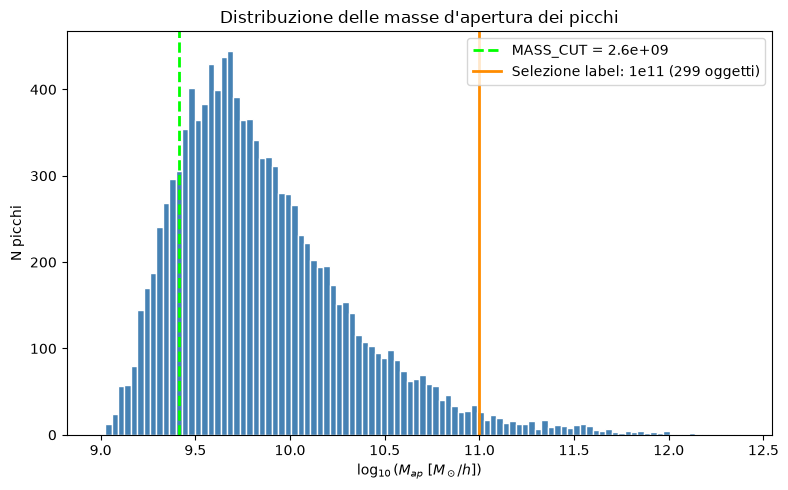

In [6]:
# %% ── 5. Massa d'apertura e significanza dei picchi (DIAGNOSTICA esplorativa) ─
# Obiettivo: associare a ogni picco una massa fisica (M_ap) e una significanza.
# Serve alla figura richiesta dal prof (M_ap picchi vs GroupMass catalogo) e ai
# numeri della fase catalog-free. Saltata se RUN_PEAK_DIAGNOSTICS=False.

rho_c = 2.775e11
if not (RUN_PEAK_DIAGNOSTICS and peak_catalogue):
    print("Diagnostica picchi disattivata (RUN_PEAK_DIAGNOSTICS=False): blocco skipped.")

# ── (1) Calibrazione unità per fetta (conservazione della massa) ─────────────
# mpu × valore_pixel = M☉/h.  mpu = massa vera della fetta / somma dell'immagine.
mpu_list = []
for pos, info in enumerate(peak_catalogue):
    n_sl = int(((z >= info["z_lo"]) & (z < info["z_hi"])).sum())
    mpu_list.append((n_sl * dm_mass)
                    / float(np.sum(images_density_list[pos], dtype=np.float64)))
mpu_arr = np.array(mpu_list)
print(f"=== Calibrazione unità ===")
print(f"  mpu per fetta: min={mpu_arr.min():.4g}  max={mpu_arr.max():.4g}  "
      f"(spread {100*(mpu_arr.max()-mpu_arr.min())/mpu_arr.mean():.1f}%)")
print("  (coerenti tra fette → il render conserva la massa, le M_ap sono fisiche)")

# ── (2) Per fetta: background/smooth una volta, poi M_ap, R200 e S per picco ─
all_S_list = []
for pos, info in enumerate(peak_catalogue):
    img = images_density_list[pos]
    mpu = mpu_list[pos]

    # Significanza: smooth del log-densità UNA volta per fetta
    sm = gaussian_filter(np.log10(img + EPS), 1.5, mode='grid-wrap')
    bg_sm = float(np.median(sm))
    sg    = (np.percentile(sm, 84) - np.percentile(sm, 16)) / 2.0
    sig   = (np.asarray(info["peak_logvals"], dtype=float) - bg_sm) / sg
    all_S_list.append(sig)

    # M_ap(<R_1/e) per ogni picco: disco periodico, background sottratto
    bg  = float(np.median(img))                    # background in scala lineare
    pk  = np.asarray(info["peaks_px"])
    rpx = np.asarray(info["radii_px"], dtype=float)
    m_ap = np.empty(len(pk))
    for k in range(len(pk)):
        rc, cc = int(pk[k, 0]), int(pk[k, 1])
        r  = max(1.0, rpx[k]); ri = int(np.ceil(r))
        ys = np.arange(rc - ri, rc + ri + 1) % IMG_SIZE
        xs = np.arange(cc - ri, cc + ri + 1) % IMG_SIZE
        YY, XX = np.meshgrid(ys, xs, indexing='ij')
        dy = np.abs(YY - rc); dy = np.minimum(dy, IMG_SIZE - dy)
        dx = np.abs(XX - cc); dx = np.minimum(dx, IMG_SIZE - dx)
        disk = (dx*dx + dy*dy) <= r*r
        m_ap[k] = (img[np.ix_(ys, xs)][disk].sum(dtype=np.float64)
                   - bg * disk.sum()) * mpu

    info["M_ap_msun"]    = m_ap
    info["significance"] = sig                       # salvato nel catalogue
    # R200 stimato invertendo M200 = 200·rho_c·(4/3)πR³  →  R = [3M/(800π·rho_c)]^(1/3)
    info["R200_est_mpc"] = (3.0 * np.maximum(m_ap, 1e-10) / (800 * np.pi * rho_c)) ** (1/3)

# ── (3) Riepiloghi ────────────────────────────────────────────────────────────
all_M  = np.concatenate([i["M_ap_msun"]      for i in peak_catalogue])
all_S  = np.concatenate(all_S_list)
all_R2 = np.concatenate([i["R200_est_mpc"]   for i in peak_catalogue])
all_R1 = np.concatenate([np.asarray(i["radii_mpc"], float) for i in peak_catalogue])

print("\n=== Conteggi per soglia di massa ===")
for Mmin in [MASS_CUT_MSUN, 1e10, 3e10, 1e11, 3e11]:
    n = int((all_M >= Mmin).sum())
    print(f"  M_ap ≥ {Mmin:.1e} : {n:>6,}  ({n/len(all_M)*100:5.1f}%)")

print(f"\n=== R200 dalla massa vs criterio 1/e ===")
rat = all_R2 / np.maximum(all_R1, 1e-6)
print(f"  R200/R_1e : mediana={np.median(rat):.2f}  "
      f"P16={np.percentile(rat,16):.2f}  P84={np.percentile(rat,84):.2f}")
print(f"  R200 max  : {all_R2.max()*1000:.0f} ckpc/h  "
      f"(2R = {2*all_R2.max()*1000:.0f}  vs  Δz = {SLICE_DZ*1000:.0f})")

# ── (4b) Istogramma delle masse d'apertura ───────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(np.log10(all_M), bins=100, color='steelblue', edgecolor='white')

ax.axvline(np.log10(MASS_CUT_MSUN), color='lime', ls='--', lw=2,
           label=f'MASS_CUT = {MASS_CUT_MSUN:.1e}')
ax.axvline(11.0, color='darkorange', ls='-', lw=2,
           label='Selezione label: 1e11 (299 oggetti)')

ax.set_xlabel(r'$\log_{10}(M_{ap}\ [M_\odot/h])$')
ax.set_ylabel('N picchi')
ax.set_title("Distribuzione delle masse d'apertura dei picchi")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "aperture_mass_hist.png"), dpi=150)
plt.show()

# ── (5) Figura richiesta dal prof: GroupMass catalogo vs M_ap dei picchi ─────
if RUN_PEAK_DIAGNOSTICS and peak_catalogue:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(np.log10(halo_mass), bins=100, histtype="stepfilled", alpha=0.45,
            color="tab:blue", label=f"catalogo FoF/SubFind M≥MASS_CUT (N={n_cat_sel:,})")
    ax.hist(np.log10(all_M), bins=100, histtype="step", lw=2, color="tab:red",
            label=f"picchi SPH @ {PEAK_THRESHOLD_SIG}σ (N={len(all_M):,})")
    ax.axvline(np.log10(MASS_CUT_MSUN), color="lime", ls="--", lw=2,
               label=f"MASS_CUT = {MASS_CUT_MSUN:.1e}")
    ax.set_xlabel(r"$\log_{10}(M\ [M_\odot/h])$")
    ax.set_ylabel("N oggetti")
    ax.set_title("Label da catalogo (blu) vs massa d'apertura dei picchi (rosso)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "mass_comparison_catalog_vs_peaks.png"), dpi=150)
    plt.show()

    n_peak_1e11 = int((all_M >= 1e11).sum())
    print("\n=== Confronto richiesto dal prof (conteggi) ===")
    print(f"  Aloni catalogo sopra MASS_CUT       : {n_cat_sel:,}")
    print(f"  Picchi rilevati @ {PEAK_THRESHOLD_SIG}σ (tutte le fette) : {len(all_M):,}"
          f"   ({len(all_M)/max(n_cat_sel,1):.1f}× il catalogo)")
    print(f"  Picchi con M_ap ≥ 1e11              : {n_peak_1e11:,}")


## 6) Normalizzazione
Normalizzazione robusta del **canale unico di densità** su tutte le slice per coerenza inter-fetta.
Il canale h_map (CH2) non viene più normalizzato né salvato: eliminato dall'input in v3.

In [7]:
# ── Normalizzazione robusta (V3: solo CH1 density) ───────────────────────────
# CH1 (density): log10 + z-score robusto (mediana + sigma P84-P16), calcolato su
# TUTTE le fette insieme per coerenza inter-fetta.
# CH2 (h_map) ELIMINATO in v3: h ∝ ρ^(-1/3) → nessuna informazione nuova
# (Spearman ρ = +0.81 misurato in v2.x; decisione prof 29/09).

all_log_density = np.concatenate(
    [np.log10(img.ravel().astype(np.float64) + EPS) for img in images_density_list]
)
MED_D  = float(np.median(all_log_density))
SIG_D  = (np.percentile(all_log_density, 84) - np.percentile(all_log_density, 16)) / 2.0

print("=== Statistiche normalizzazione (1 canale) ===")
print(f"  CH1 density : mediana={MED_D:.4f}  sigma_rob={SIG_D:.4f}")


def normalize_density(img):
    return (np.log10(img.astype(np.float64) + EPS) - MED_D) / SIG_D


images_density_norm = [normalize_density(img) for img in images_density_list]

# norm_stats: shape (1,2) = [[MED_D, SIG_D]]  (la seconda riga CH2 di v2.x è eliminata)
norm_stats = np.array([[MED_D, SIG_D]], dtype=np.float32)
np.save(os.path.join(OUTPUT_DIR, "norm_stats.npy"), norm_stats)
print("Norm stats salvate (1 canale).")

=== Statistiche normalizzazione ===
  CH1 density : mediana=9.9753  sigma_rob=0.3576
  CH2 h_map   : mediana=0.3499  sigma_rob=0.0663
Norm stats salvate.


## 7) Estrazione patch, salvataggio e controlli finali
Estrazione del dataset finale (**X a 1 canale**, Y = maschera binaria da catalogo + heatmap/raggio
CenterNet-style per lo stadio 2), salvataggio artefatti e riepilogo sintetico delle statistiche.

In [8]:
# ── Estrazione patch (V3: input 1 canale) ─────────────────────────────────────
# X          : (N, 1, PATCH_SIZE, PATCH_SIZE) float32   — solo densità SPH normalizzata
# Y_mask     : (N, PATCH_SIZE, PATCH_SIZE) uint8        — label primaria U-Net (0/1, da catalogo)
# Y_heatmap  : (N, PATCH_SIZE, PATCH_SIZE) float32      — blob gaussiano (stadio 2 / StarDist-like)
# Y_radius   : (N, PATCH_SIZE, PATCH_SIZE) float32      — mappa raggi R200c in px (stadio 2)
# Tutte le patch incluse (anche quelle vuote): la rete impara che il cielo è perlopiù vuoto.

def extract_patches_1ch(density_norm, mask_bin, heatmap, radius_map, patch_size):
    H, W = density_norm.shape
    x_p, ym_p, yh_p, yr_p = [], [], [], []
    for r in range(0, H - patch_size + 1, patch_size):
        for c in range(0, W - patch_size + 1, patch_size):
            ch1 = density_norm[r:r+patch_size, c:c+patch_size].astype(np.float32)
            x_p .append(ch1[np.newaxis, :, :])
            ym_p.append(mask_bin  [r:r+patch_size, c:c+patch_size])
            yh_p.append(heatmap   [r:r+patch_size, c:c+patch_size])
            yr_p.append(radius_map[r:r+patch_size, c:c+patch_size])
    return x_p, ym_p, yh_p, yr_p


X_patches, Y_mask_patches, Y_heat_patches, Y_rad_patches = [], [], [], []
for dn, mb, heat, rmap in zip(images_density_norm, mask_bin_list,
                              heatmaps_list, radius_maps_list):
    xp, ymp, yh, yr = extract_patches_1ch(dn, mb, heat, rmap, PATCH_SIZE)
    X_patches.extend(xp);      Y_mask_patches.extend(ymp)
    Y_heat_patches.extend(yh); Y_rad_patches.extend(yr)

X      = np.stack(X_patches)       .astype(np.float32)
Y_mask = np.stack(Y_mask_patches)  .astype(np.uint8)
Y_heat = np.stack(Y_heat_patches)  .astype(np.float32)
Y_rad  = np.stack(Y_rad_patches)   .astype(np.float32)

n_pos = int((Y_mask.max(axis=(1, 2)) > 0).sum())

print("=== Patch dataset (v3) ===")
print(f"  X shape          : {X.shape}  (N, 1, H, W)")
print(f"  Y_mask shape     : {Y_mask.shape}  (uint8 0/1, label primaria)")
print(f"  Y_heatmap shape  : {Y_heat.shape}")
print(f"  Y_radius shape   : {Y_rad.shape}")
print(f"  Patch positive   : {n_pos} / {len(X)}  ({n_pos/len(X)*100:.1f}%)")
print(f"  Max heatmap      : {Y_heat.max():.4f}")
print(f"  Max radius (px)  : {Y_rad.max():.1f}  (= R200c max del catalogo in px)")
print(f"  Memoria X        : {X.nbytes/1e6:.1f} MB")

# ── Salvataggio dataset ────────────────────────────────────────────────────────
X_path  = os.path.join(OUTPUT_DIR, "X_patches.npy")
Ym_path = os.path.join(OUTPUT_DIR, "Y_mask_patches.npy")
Yh_path = os.path.join(OUTPUT_DIR, "Y_heatmap_patches.npy")
Yr_path = os.path.join(OUTPUT_DIR, "Y_radius_patches.npy")

np.save(X_path,  X)
np.save(Ym_path, Y_mask)
np.save(Yh_path, Y_heat)
np.save(Yr_path, Y_rad)
if RUN_PEAK_DIAGNOSTICS and peak_catalogue:
    np.save(os.path.join(OUTPUT_DIR, "peak_catalogue.npy"),
            np.array(peak_catalogue, dtype=object), allow_pickle=True)
np.save(os.path.join(OUTPUT_DIR, "halo_catalogue_slices.npy"),
        np.array(halo_catalogue, dtype=object), allow_pickle=True)

print("=== Dataset salvato ===")
print(f"  X         → {X_path}      ({X.nbytes/1e6:.1f} MB)")
print(f"  Y_mask    → {Ym_path}  ({Y_mask.nbytes/1e6:.1f} MB)")
print(f"  Y_heatmap → {Yh_path}  ({Y_heat.nbytes/1e6:.1f} MB)")
print(f"  Y_radius  → {Yr_path}   ({Y_rad.nbytes/1e6:.1f} MB)")

info_lines = [
    "=== CAMELS Preprocessing v3.0 — Label from FoF/SubFind catalogue ===",
    f"Snapshot        : snapshot_090.hdf5  (z = {redshift:.4f})",
    "Catalogo label  : groups_090.hdf5  (FoF+SubFind; GroupPos, GroupMass, Group_R_Crit200)",
    f"Box size        : {Lbox:.4f} Mpc/h",
    f"N particles     : {len(x):,}  ({round(len(x)**(1/3))}³)",
    f"DM particle mass: {dm_mass:.3e} M☉/h",
    "",
    "--- Input (1 canale) ---",
    f"CH1 density     : SPH render  r_max={R_MAX_LEVEL}  target_cells={TARGET_CELLS}",
    "CH2 h_map       : ELIMINATO in v3 (h ∝ ρ^(-1/3), Spearman ρ=+0.81; decisione prof 29/09)",
    "",
    "--- Label (dal catalogo) ---",
    f"Sorgente        : verità-terra = catalogo FoF+SubFind (decisione 29/09)",
    f"Selezione       : GroupMass ≥ {MASS_CUT_MSUN:.2e} M☉/h (N_min={N_MIN_PARTICLES}) e R_Crit200 > 0",
    f"Aloni selezionati: {n_cat_sel:,} / {n_cat_total:,} nel file",
    f"Assegnazione fetta : weighting \"{HALO_WEIGHTING}\" (\"center\": centro z∈[z_lo,z_hi); \"fraction\": frazione di sfera R200c nella fetta)",
    f"Formati Y       : Y_mask (binaria uint8, U-Net baseline) + Y_heatmap/Y_radius (CenterNet-style, stadio 2)",
    f"Geometria       : periodica (wrap ai bordi, distanza min(|d|, N−|d|)); r_px = R200c/Lbox×IMG_SIZE, floor {MIN_RADIUS_PX} px",
    "",
    "--- Slicing ---",
    f"N slices        : {N_SLICES}",
    f"Slice Δz        : {SLICE_DZ*1000:.1f} ckpc/h = {SLICE_DZ:.4f} Mpc/h",
    "",
    "--- Normalizzazione ---",
    f"CH1 MED/SIG     : {MED_D:.4f} / {SIG_D:.4f}  (log10 + robust z-score); norm_stats.npy shape (1,2)",
    "",
    "--- Patch dataset ---",
    f"Patch size      : {PATCH_SIZE} × {PATCH_SIZE} px",
    f"Total patches   : {len(X):,}",
    f"Positive patches: {n_pos:,}  ({n_pos/len(X)*100:.1f}%)",
    f"X shape         : {X.shape}",
    f"Y_mask shape    : {Y_mask.shape}",
    f"Y_heatmap shape : {Y_heat.shape}",
    f"Y_radius shape  : {Y_rad.shape}",
    "",
    "--- NOTA training (P2-04) ---",
    "Normalizzare Y_rad prima del training per stabilità della regressione L1:",
    "  opzione A) Y_rad_norm = Y_rad / 80.0          (lineare, max atteso ≈ 80 px)",
    "  opzione B) Y_rad_norm = log1p(Y_rad) / log1p(80)  (compressa, robusta agli outlier)",
    "",
    "--- File di output ---",
    "X_patches.npy (1 canale), Y_mask_patches.npy, Y_heatmap_patches.npy, Y_radius_patches.npy",
    "norm_stats.npy (1,2), halo_catalogue_slices.npy",
    "slices_density_raw.npy  [input X riutilizzabile]",
    "smoothing_lengths_090_k32.npy",
]
if RUN_PEAK_DIAGNOSTICS:
    info_lines += [
        "",
        "--- Diagnostica esplorativa (fase catalog-free v2.x) ---",
        f"Picchi @ {PEAK_THRESHOLD_SIG}σ    : {sum(len(p['peaks_px']) for p in peak_catalogue):,}",
        "peak_catalogue.npy: masse d'apertura, R200_est, significanza, group_id/is_primary",
        "Figura: mass_comparison_catalog_vs_peaks.png (GroupMass vs M_ap, richiesta prof)",
    ]
info_text = "\n".join(info_lines)
print("\n" + info_text)
with open(os.path.join(OUTPUT_DIR, "dataset_info.txt"), "w", encoding="utf-8") as f:
    f.write(info_text)

# ── Blocco de-duplicazione picchi appeso a dataset_info.txt (solo diagnostica) ─
if RUN_PEAK_DIAGNOSTICS and peak_catalogue:
    n_primtot = sum(len(i["radii_px"]) for i in peak_catalogue)
    n_sec   = sum(int((~np.asarray(i["is_primary"], dtype=bool)).sum())
                  for i in peak_catalogue)
    txt = (
        "\n--- De-duplicazione inter-fetta dei PICCHI (diagnostica, FIX tolleranza fissa) ---\n"
        f"Picchi totali       : {n_primtot:,}\n"
        f"Oggetti unici (3D)  : {len(groups_summary)}\n"
        f"Gruppi multi-fetta  : {sum(g['is_multi'] for g in groups_summary)}"
        f"   (picchi secondari: {n_sec}, {n_sec/max(n_primtot,1)*100:.1f}%)\n"
        f"Tolleranza match    : {TOL_MATCH:.3f} Mpc/h ({TOL_MATCH/pixel_size_mpc:.0f} px), FISSA in xy\n"
        "Nota                : 'is_primary' va usato SOLO in validazione (es. HMF: contare i soli primari).\n"
    )
    with open(os.path.join(OUTPUT_DIR, "dataset_info.txt"), "a", encoding="utf-8") as f:
        f.write(txt)
    print("dataset_info.txt aggiornato con il blocco de-duplicazione picchi.")

=== Patch dataset ===
  X shape          : (400, 2, 256, 256)  (N, canali, H, W)
  Y_heatmap shape  : (400, 256, 256)
  Y_radius shape   : (400, 256, 256)
  Patch positive   : 397 / 400  (99.2%)
  Max heatmap      : 1.0000  (deve essere ≈ 1.0)
  Max radius (px)  : 51.0
  Memoria X        : 209.7 MB
=== Dataset salvato ===
  X          → C:\Users\kekko\Downloads\Python\TESI\CAMELS_data\preprocessed_v2.1\X_patches.npy      (209.7 MB)
  Y_heatmap  → C:\Users\kekko\Downloads\Python\TESI\CAMELS_data\preprocessed_v2.1\Y_heatmap_patches.npy  (104.9 MB)
  Y_radius   → C:\Users\kekko\Downloads\Python\TESI\CAMELS_data\preprocessed_v2.1\Y_radius_patches.npy   (104.9 MB)
  Catalogo   → C:\Users\kekko\Downloads\Python\TESI\CAMELS_data\preprocessed_v2.1\peak_catalogue.npy

=== CAMELS Preprocessing v2.1 — Heatmap Labels from SPH ===
Snapshot        : snapshot_090.hdf5  (z = 0.0000)
Box size        : 25.0000 Mpc/h
N particles     : 16,777,216  (256³)
DM particle mass: 2.600e+07 M☉/h

--- Input (2 cana

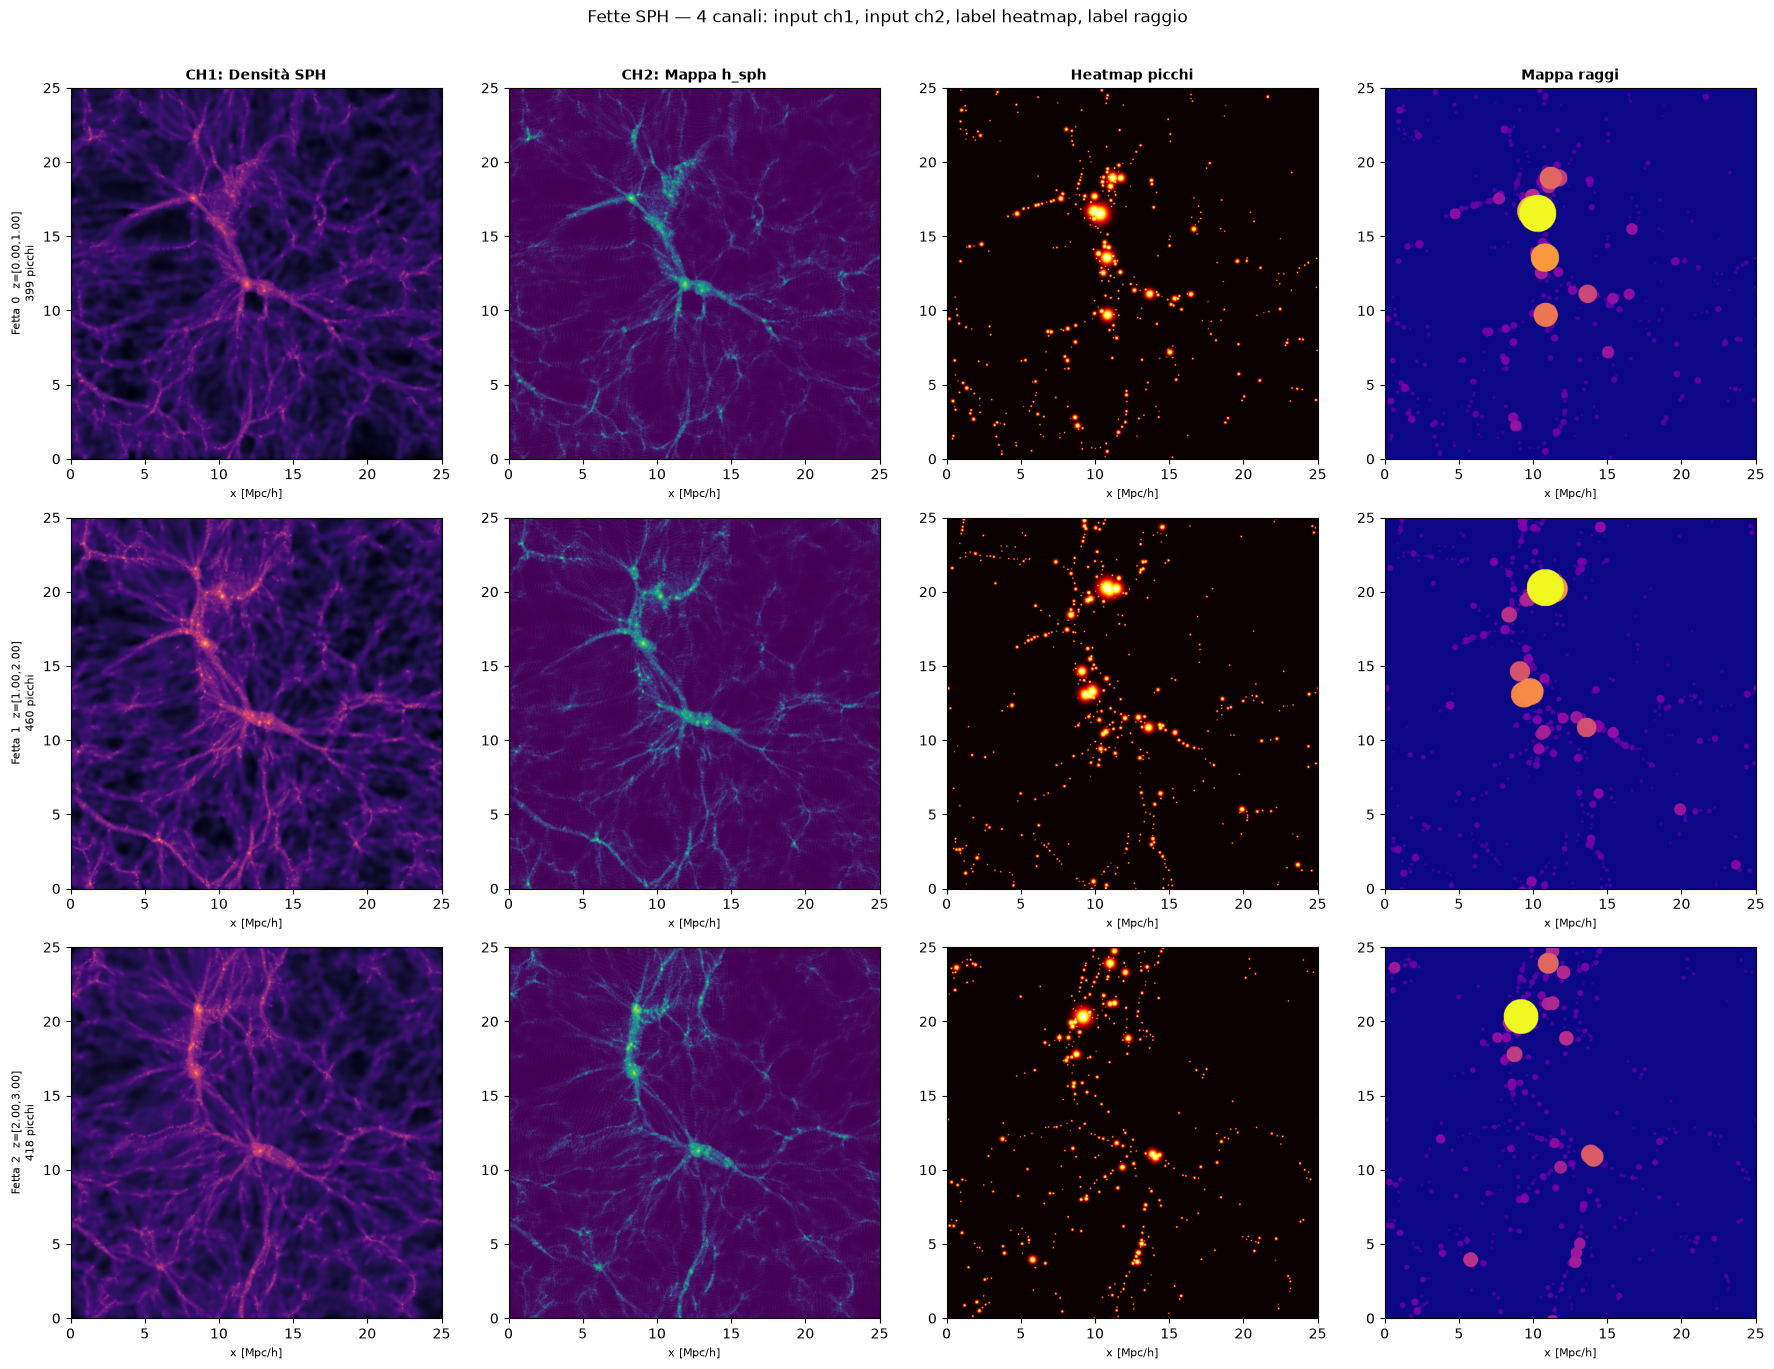

In [9]:
# %% ── 9. Visualizzazione ──────────────────────────────────────────────────────

# P2-05: rng_vis con seed fisso per riproducibilità
rng_vis = np.random.default_rng(0)

# ── 9a. Fette campione (4 pannelli) ──────────────────────────────────────────
n_show_slices = min(3, len(images_density_norm))
fig, axes = plt.subplots(n_show_slices, 4,
                         figsize=(18, 4.5 * n_show_slices))
if n_show_slices == 1:
    axes = axes[np.newaxis, :]

col_titles = ["CH1: Densità SPH (input)", "Y_mask: catalogo FoF (label)", "Y_heatmap (stadio 2)", "Y_radius R200c (px)"]
for j, t in enumerate(col_titles):
    axes[0, j].set_title(t, fontsize=10, fontweight='bold')

for i in range(n_show_slices):
    z_lo, z_hi, n_peaks = slice_info[i]
    kw = dict(origin='lower', extent=[0, Lbox, 0, Lbox])
    axes[i, 0].imshow(images_density_norm[i], cmap='magma',   **kw)
    axes[i, 1].imshow(mask_bin_list      [i], cmap='gray_r',  **kw, vmin=0, vmax=1)
    axes[i, 2].imshow(heatmaps_list      [i], cmap='hot',     **kw, vmin=0, vmax=1)
    axes[i, 3].imshow(radius_maps_list   [i], cmap='plasma',  **kw)
    for j in range(4):
        axes[i, j].set_xlabel('x [Mpc/h]', fontsize=8)
    axes[i, 0].set_ylabel(
        f"Fetta {i}  z=[{z_lo:.2f},{z_hi:.2f}]\n{n_peaks} picchi", fontsize=8)

plt.suptitle("Fette SPH v3 — input 1 canale + label dal catalogo (maschera, heatmap, raggio)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sample_slices_v3.png"), dpi=150, bbox_inches='tight')
plt.show()

Fetta : idx=12 z=[12.00,13.00] | 900,124 particelle
Patch : idx=192 (local=0, row=0, col=0)


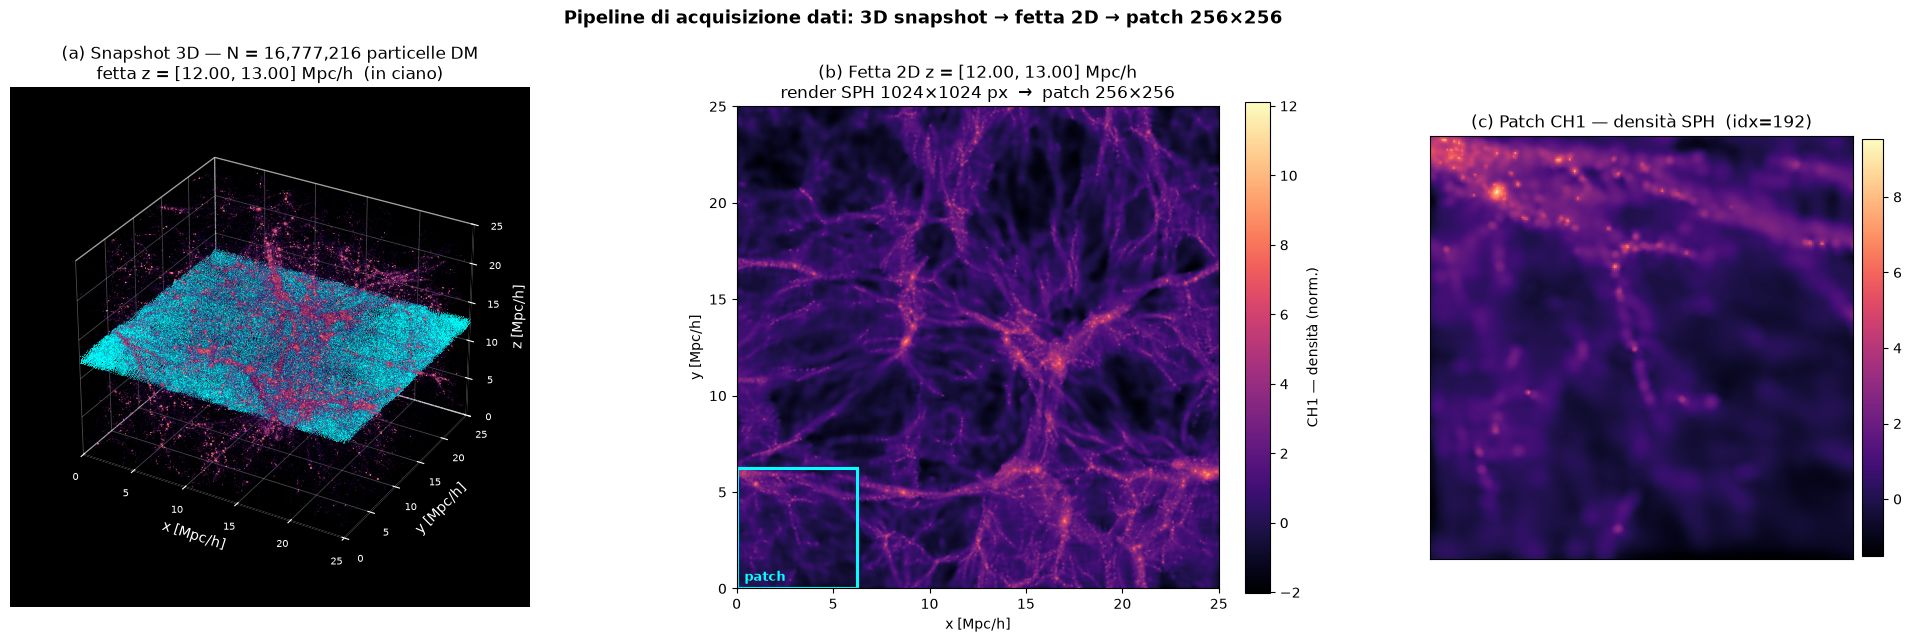

In [ ]:
# %% ── 12. Visualizzazione pipeline (stile cosmic web) — versione compatta/veloce
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams["figure.dpi"] = 100          # rendering più rapido in notebook

# ── Parametri ────────────────────────────────────────────────────────────
SLICE_IDX_SHOW, PATCH_LOCAL_IDX = 12, None   # None → patch con max heatmap
N_3D_SHOW, SEED_3D = 400_000, 0
PPS = IMG_SIZE // PATCH_SIZE                 # patches per side (= 4)

# ── Fetta + patch ────────────────────────────────────────────────────────
SLICE_IDX_SHOW = min(SLICE_IDX_SHOW, len(slice_info) - 1)
z_lo_s, z_hi_s, _ = slice_info[SLICE_IDX_SHOW]
mask_slice = (z >= z_lo_s) & (z < z_hi_s)

base = SLICE_IDX_SHOW * PPS**2
if PATCH_LOCAL_IDX is None:      # max heatmap nella fetta (come nell'originale)
    PATCH_LOCAL_IDX = int(Y_heat[base:base + PPS**2].max(axis=(1, 2)).argmax())
patch_idx = base + PATCH_LOCAL_IDX
p_row, p_col = divmod(PATCH_LOCAL_IDX, PPS)
x0, y0, w = p_col * Lbox / IMG_SIZE * PATCH_SIZE, p_row * Lbox / IMG_SIZE * PATCH_SIZE, \
            PATCH_SIZE / IMG_SIZE * Lbox           # riquadro patch in Mpc/h

print(f"Fetta : idx={SLICE_IDX_SHOW} z=[{z_lo_s:.2f},{z_hi_s:.2f}] | {mask_slice.sum():,} particelle")
print(f"Patch : idx={patch_idx} (local={PATCH_LOCAL_IDX}, row={p_row}, col={p_col})")

# ── Sottocampionamento 3D (un solo indice, niente double-gather) ────────
idx_3d = np.random.default_rng(SEED_3D).choice(len(x), min(N_3D_SHOW, len(x)), replace=False)
idx_sl = np.flatnonzero(mask_slice)                  # più rapido di np.where
neg_log_h = -np.log10(h_sph[idx_3d] + 1e-6)          # h piccolo → zona densa
lo, hi = np.percentile(neg_log_h, [2, 98])
d = np.clip((neg_log_h - lo) / (hi - lo), 0, 1)

# ── Figura ───────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 6.5))
gs = fig.add_gridspec(1, 3, wspace=.30, width_ratios=[1.15, 1, .85],
                      left=.02, right=.98, bottom=.10, top=.90)

# (a) Snapshot 3D — nuvola + piani fetta + particelle della fetta
ax = fig.add_subplot(gs[0, 0], projection='3d', facecolor='black')
sc_kw = dict(linewidths=0, depthshade=False, rasterized=True)
ax.scatter(x[idx_3d], y[idx_3d], z[idx_3d], c=d, cmap='magma', s=.35, alpha=.35, **sc_kw)
XX, YY = np.meshgrid([0, Lbox], [0, Lbox])
for zc in (z_lo_s, z_hi_s):
    ax.plot_surface(XX, YY, np.full_like(XX, zc), alpha=.08, color='cyan', shade=False)
ax.scatter(x[idx_sl], y[idx_sl], z[idx_sl], c='cyan', s=.6, alpha=.55, **sc_kw)

ax.set(xlabel='x [Mpc/h]', ylabel='y [Mpc/h]', zlabel='z [Mpc/h]',
       xlim=(0, Lbox), ylim=(0, Lbox), zlim=(0, Lbox),
       title=f"(a) Snapshot 3D — N = {n_particles:,} particelle DM\n"
             f"fetta z = [{z_lo_s:.2f}, {z_hi_s:.2f}] Mpc/h  (in ciano)")
ax.tick_params(colors='white', labelsize=7)
for lab in 'xyz':
    a = getattr(ax, f'{lab}axis')
    a.label.set_color('white'); a.pane.set_facecolor((0, 0, 0, 1)); a.pane.set_edgecolor((1, 1, 1, .35))
    a._axinfo['grid'].update(color=(1, 1, 1, .30), linewidth=.6)
    a._axinfo['axisline']['color'] = (1, 1, 1, .6)
ax.set_box_aspect([1.15, 1, .85], zoom=.85)

# (b) Fetta 2D + riquadro patch
im = fig.add_subplot(gs[0, 1]).imshow(images_density_norm[SLICE_IDX_SHOW], cmap='magma',
                                      origin='lower', extent=[0, Lbox, 0, Lbox])
plt.gca().add_patch(Rectangle((x0, y0), w, w, lw=2.2, ec='cyan', fc='none'))
plt.gca().text(x0 + .4, y0 + .4, 'patch', color='cyan', fontsize=9, fontweight='bold')
plt.gca().set(xlabel='x [Mpc/h]', ylabel='y [Mpc/h]',
              title=f"(b) Fetta 2D z = [{z_lo_s:.2f}, {z_hi_s:.2f}] Mpc/h\n"
                    f"render SPH {IMG_SIZE}×{IMG_SIZE} px  →  patch {PATCH_SIZE}×{PATCH_SIZE}")
plt.colorbar(im, fraction=.046, label='CH1 — densità (norm.)')

# (c) Patch CH1 — densità SPH
axp = fig.add_subplot(gs[0, 2])
axp.imshow(X[patch_idx, 0], cmap='magma', origin='lower')
axp.set(title=f"(c) Patch CH1 — densità SPH  (idx={patch_idx})", xticks=[], yticks=[])
plt.colorbar(axp.images[0], ax=axp, fraction=.046, pad=.02)

fig.suptitle("Pipeline di acquisizione dati: 3D snapshot → fetta 2D → patch 256×256",
             fontsize=13, fontweight='bold', y=1.02)
fig.savefig(os.path.join(OUTPUT_DIR, "pipeline_visualization.png"),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()